In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/spscientist/students-performance-in-exams/StudentsPerformance.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/spscientist/students-performance-in-exams/StudentsPerformance.csv")
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [4]:
x = df[["math score", "reading score"]]
y = df["writing score"]

In [5]:
xtrain,xtest, ytrain, ytest = train_test_split(x,y,test_size = 0.2, random_state=42)

model = LinearRegression()

model.fit(xtrain, ytrain)

prediction = model.predict(xtest)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


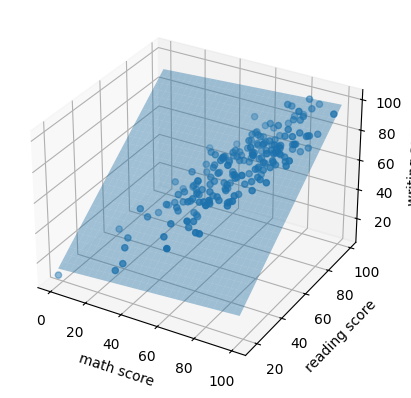

In [6]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(111,projection="3d")
ax.scatter(xtest["math score"],xtest["reading score"], ytest)
ax.set_xlabel("math score")
ax.set_ylabel("reading score")
ax.set_zlabel("writing score")


x1 = np.linspace(xtest["math score"].min(), xtest["math score"].max(), 30)
x2 = np.linspace(xtest["reading score"].min(), xtest["reading score"].max(), 30)

X1, X2 = np.meshgrid(x1, x2)

grid = np.c_[X1.ravel(), X2.ravel()]
Z = model.predict(grid).reshape(X1.shape)

ax.plot_surface(
    X1,
    X2,
    Z,
    alpha=0.4
)

plt.show()